In [2]:
import os
import sys

# Change the notebook's active working directory to the project root
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

# Ensure the root path is also in sys.path
if os.getcwd() not in sys.path:
    sys.path.append(os.getcwd())


In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from src.database.connection import DatabaseConnection

In [4]:
conn = DatabaseConnection.connect()

In [5]:
query = """
SELECT
    date,
    SUM(sales) AS total_sales

FROM sales_enriched
GROUP BY date
ORDER BY date
"""

In [6]:
daily_sales = pd.read_sql(query, conn)
daily_sales.head()

C:\Users\Dell\AppData\Local\Temp\ipykernel_13596\2471162896.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  daily_sales = pd.read_sql(query, conn)


,date,total_sales
0,2011-01-29,32631.0
1,2011-01-30,31749.0
2,2011-01-31,23783.0
3,2011-02-01,25412.0
4,2011-02-02,19146.0


In [7]:
daily_sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1913 entries, 0 to 1912
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         1913 non-null   object 
 1   total_sales  1913 non-null   float64
dtypes: float64(1), object(1)
memory usage: 30.0+ KB


In [8]:
daily_sales.describe()

,total_sales
count,1913.000000
mean,34341.562467
std,7345.905196
min,11.000000
25%,29654.000000
50%,33732.000000
75%,38689.000000
max,57218.000000


In [9]:
daily_sales.head()

,date,total_sales
0,2011-01-29,32631.0
1,2011-01-30,31749.0
2,2011-01-31,23783.0
3,2011-02-01,25412.0
4,2011-02-02,19146.0


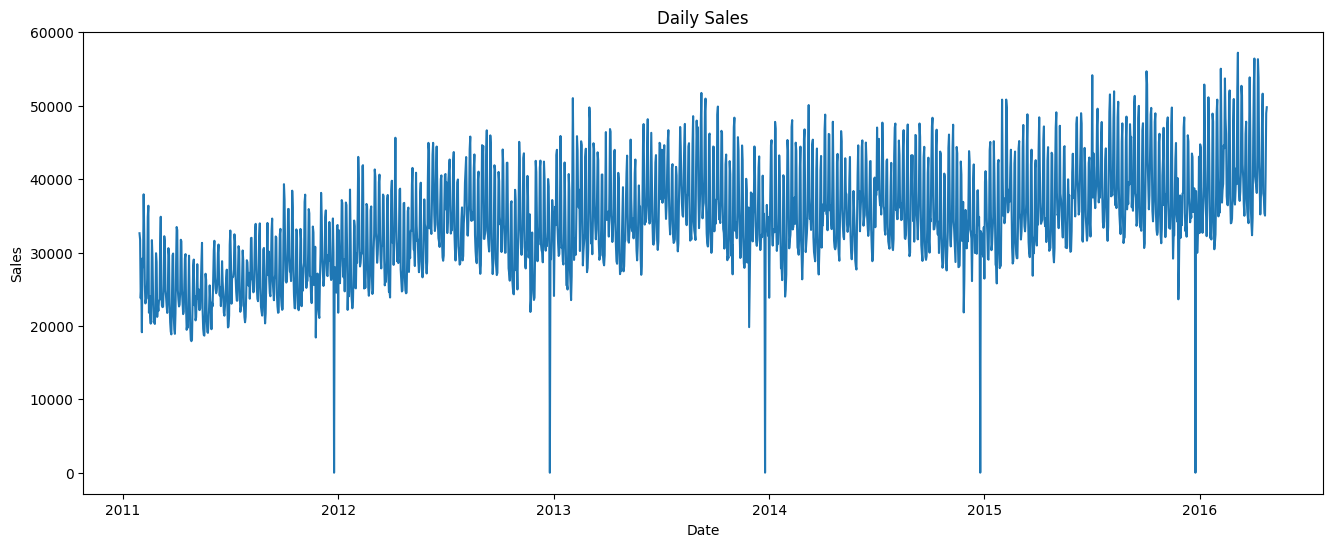

In [10]:
## Visualization
plt.figure(figsize=(16,6))

plt.plot(
    daily_sales["date"],
    daily_sales["total_sales"]
)

plt.title("Daily Sales")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.show()

### Trend analysis using moving average

In [11]:
daily_sales

,date,total_sales
0,2011-01-29,32631.0
1,2011-01-30,31749.0
2,2011-01-31,23783.0
3,2011-02-01,25412.0
4,2011-02-02,19146.0
...,...,...
1908,2016-04-20,35343.0
1909,2016-04-21,35033.0
1910,2016-04-22,40517.0
1911,2016-04-23,48962.0


In [12]:
daily_sales['date'] = pd.to_datetime(daily_sales['date'])

daily_sales['7_day_ma'] = (
    daily_sales['total_sales']
    .rolling(window=7)
    .mean()
)

daily_sales['30_day_ma'] = (
    daily_sales['total_sales']
    .rolling(window=30)
    .mean()
)

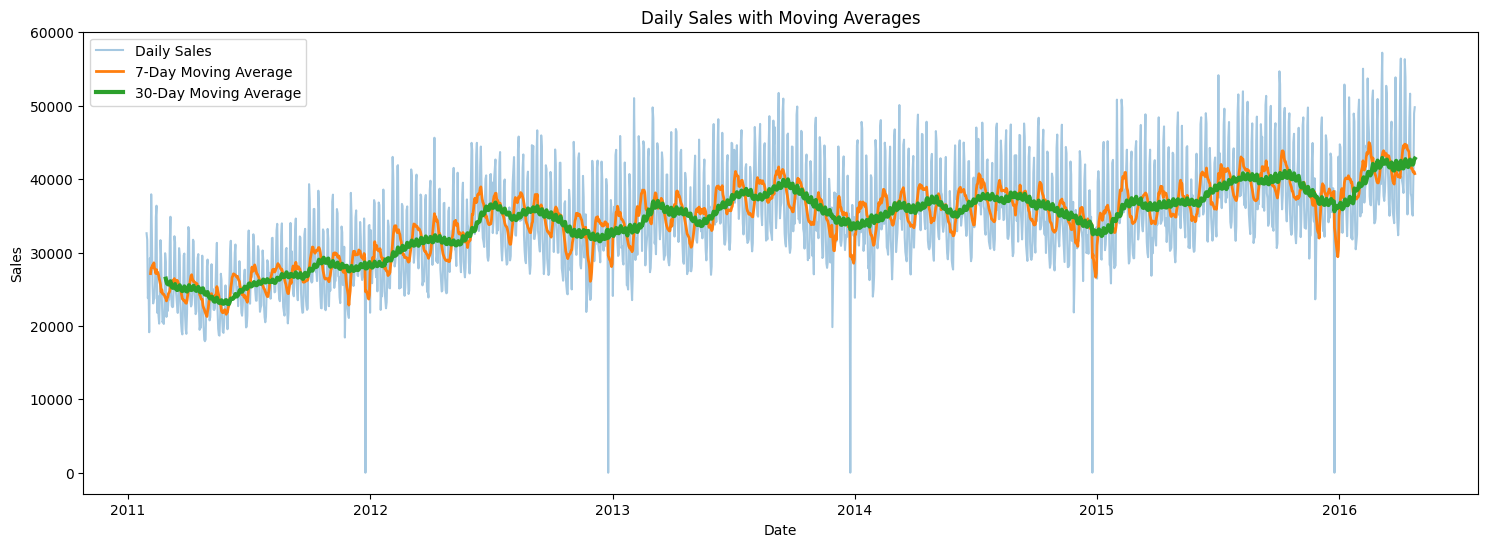

In [13]:
plt.figure(figsize=(18,6))

plt.plot(
    daily_sales["date"],
    daily_sales["total_sales"],
    alpha=0.4,
    label="Daily Sales"
)

plt.plot(
    daily_sales["date"],
    daily_sales["7_day_ma"],
    linewidth=2,
    label="7-Day Moving Average"
)

plt.plot(
    daily_sales["date"],
    daily_sales["30_day_ma"],
    linewidth=3,
    label="30-Day Moving Average"
)

plt.title("Daily Sales with Moving Averages")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()

plt.show()

## Monthly sales
    
    - which month performs the best?

In [14]:
monthly_sales = (
    daily_sales
    .groupby(
        daily_sales['date'].dt.month_name()
    )['total_sales']
    .mean()
)

In [15]:
## to keep the months in calendar order:-
month_order = [
    "January",
    "February",
    "March",
    "April",
    "May",
    "June",
    "July",
    "August",
    "September",
    "October",
    "November",
    "December"
]

monthly_sales = monthly_sales.reindex(month_order)

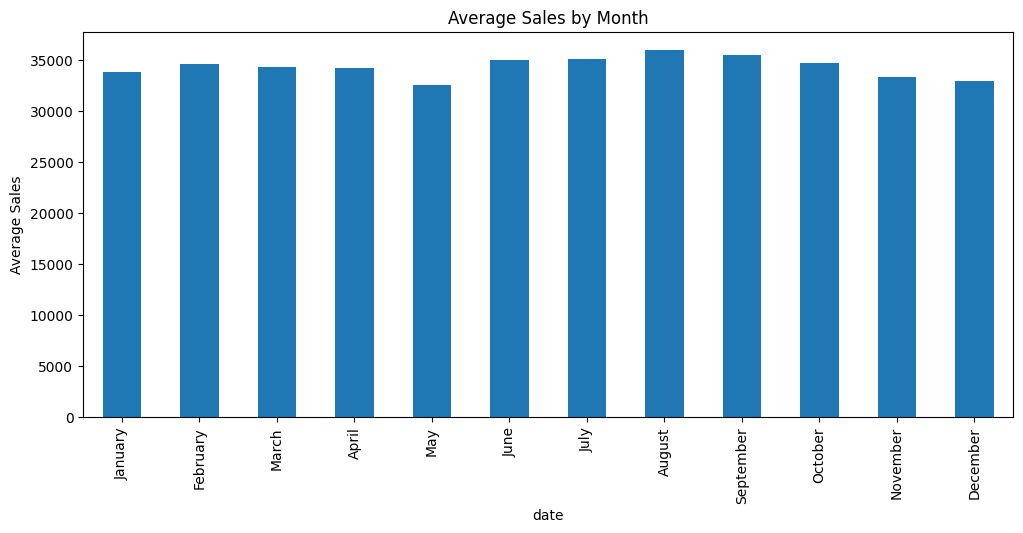

In [16]:
plt.figure(figsize=(12,5))

monthly_sales.plot(kind="bar")

plt.title("Average Sales by Month")
plt.ylabel("Average Sales")

plt.show()

## Weekly seasonality
    - Which weekday sells the most?

In [17]:
daily_sales["weekday"] = daily_sales["date"].dt.day_name()

weekday_sales = (
    daily_sales
    .groupby("weekday")["total_sales"]
    .mean()
)

weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday",
]

weekday_sales = weekday_sales.reindex(weekday_order)

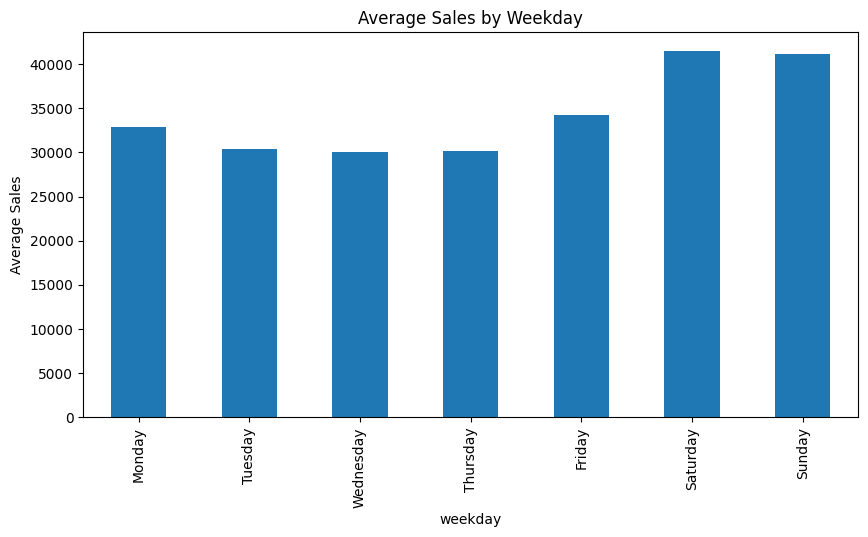

In [18]:
plt.figure(figsize=(10,5))

weekday_sales.plot(kind="bar")

plt.title("Average Sales by Weekday")

plt.ylabel("Average Sales")

plt.show()

Monthly sales
📈 August–September have the highest average sales.
📉 May is the weakest month.
Overall, there isn't an extreme monthly effect, but there is a noticeable seasonal pattern.
Weekly sales

This is even more interesting:

🛒 Saturday has the highest average sales.
🛒 Sunday is a close second.
📉 Tuesday–Thursday have the lowest demand.
Friday begins the weekend increase.

This is exactly the kind of insight a retailer could use for staffing and inventory planning.

In [19]:
yearly_sales = (
    daily_sales
    .groupby(
        daily_sales['date'].dt.year
    )['total_sales']
    .mean()
)
yearly_sales

date
2011    26280.667656
2012    32955.838798
2013    35988.364384
2014    35862.400000
2015    37810.441096
2016    41309.973913
Name: total_sales, dtype: float64

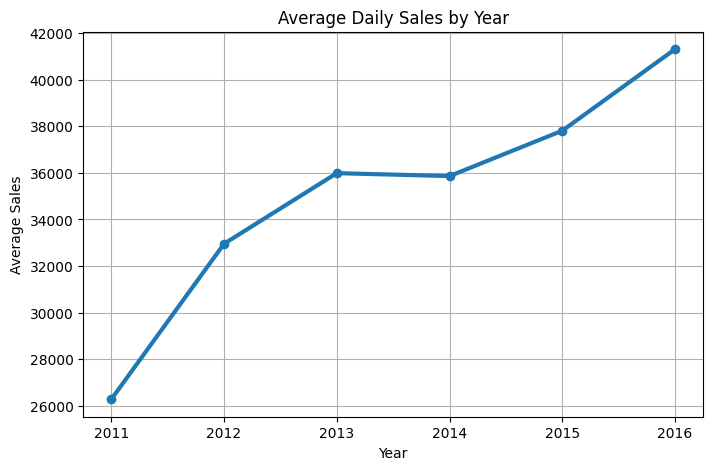

In [20]:
plt.figure(figsize=(8,5))

yearly_sales.plot(
    marker="o",
    linewidth=3
)

plt.title("Average Daily Sales by Year")
plt.xlabel("Year")
plt.ylabel("Average Sales")

plt.grid(True)

plt.show()

In [21]:
##monthly - yearly
monthly_yearly= (
    daily_sales
    .groupby([
        daily_sales['date'].dt.year,
        daily_sales['date'].dt.month
    ])['total_sales']
    .mean()
    .unstack()
)

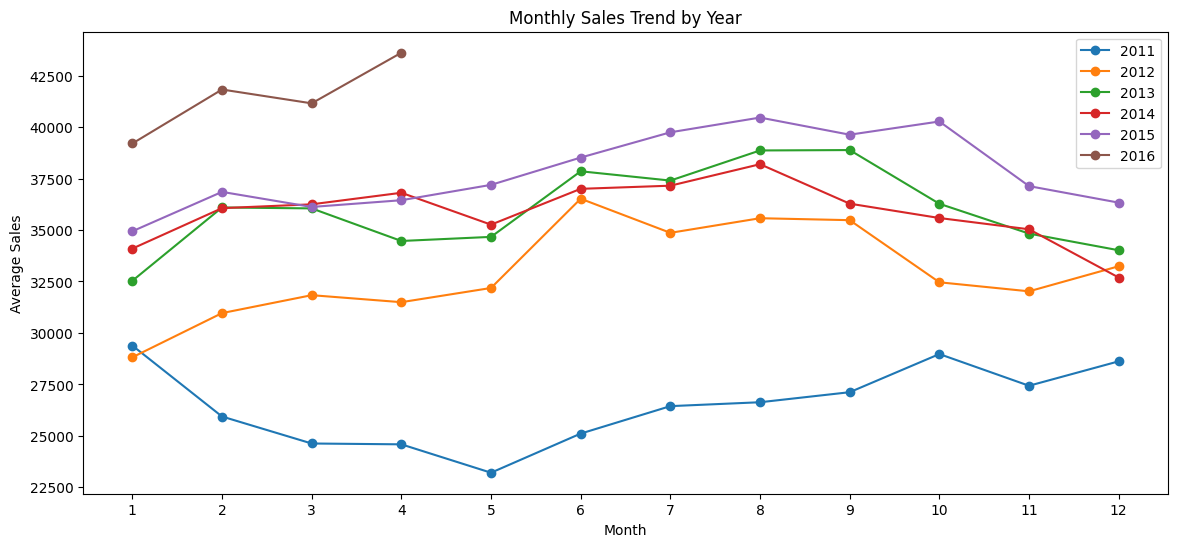

In [22]:
plt.figure(figsize=(14,6))

for year in monthly_yearly.index:

    plt.plot(
        monthly_yearly.columns,
        monthly_yearly.loc[year],
        marker="o",
        label=year
    )

plt.xticks(range(1,13))

plt.xlabel("Month")
plt.ylabel("Average Sales")

plt.title("Monthly Sales Trend by Year")

plt.legend()

plt.show()

In [23]:
holiday_query = """
SELECT

    CASE

        WHEN event_name_1 IS NULL THEN 'Non-Holiday'

        ELSE 'Holiday'

    END AS day_type,

    AVG(sales) AS avg_sales

FROM sales_enriched

GROUP BY day_type
"""

In [24]:
holiday_sales = pd.read_sql(
    holiday_query,
    conn
)

holiday_sales

C:\Users\Dell\AppData\Local\Temp\ipykernel_13596\1003874090.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  holiday_sales = pd.read_sql(


,day_type,avg_sales
0,Non-Holiday,1.1312
1,Holiday,1.0710


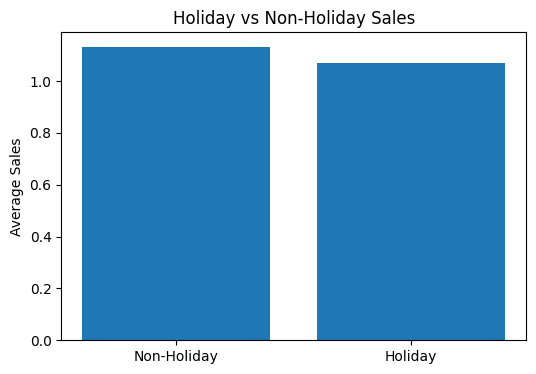

In [25]:
plt.figure(figsize=(6,4))

plt.bar(
    holiday_sales["day_type"],
    holiday_sales["avg_sales"]
)

plt.title("Holiday vs Non-Holiday Sales")

plt.ylabel("Average Sales")

plt.show()

- 📈 Trend
Average daily sales increased from ~26k (2011) to ~41k (2016).
Small plateau in 2013–2014.
Strong growth resumes after 2014.


- 📅 Monthly Seasonality
August–October are consistently among the strongest months.
May tends to be one of the weaker months.
Every year follows a similar seasonal shape.

### SNAP Analysis

In [26]:
snap_query = """
SELECT
    state_id,
    CASE
        WHEN
            (state_id='CA' AND snap_CA=1)
            OR (state_id='TX' AND snap_TX=1)
            OR (state_id='WI' AND snap_WI=1)
        THEN 'SNAP Day'
        ELSE 'Non-SNAP Day'
    END AS snap_status,

    AVG(sales) AS avg_sales

FROM sales_enriched

GROUP BY
    state_id,
    snap_status

"""

In [27]:
snap_sales = pd.read_sql(
    snap_query,
    conn
)

snap_sales

C:\Users\Dell\AppData\Local\Temp\ipykernel_13596\1717453128.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  snap_sales = pd.read_sql(


,state_id,snap_status,avg_sales
0,CA,Non-SNAP Day,1.1976
1,CA,SNAP Day,1.2932
2,TX,Non-SNAP Day,1.0407
3,TX,SNAP Day,1.1602
4,WI,Non-SNAP Day,0.9663
5,WI,SNAP Day,1.1767


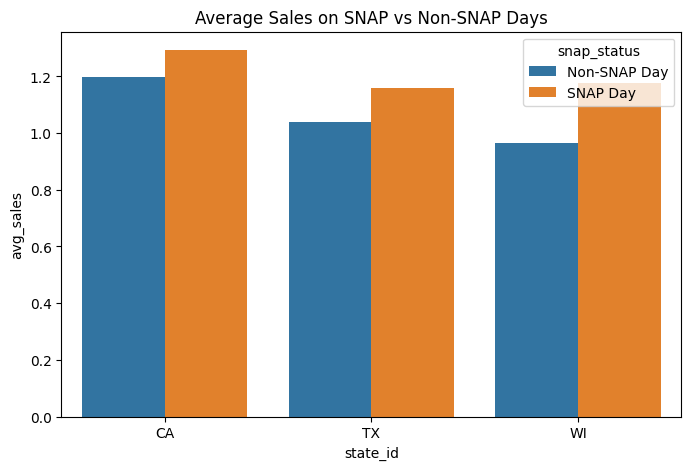

In [28]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=snap_sales,
    x="state_id",
    y="avg_sales",
    hue="snap_status"
)

plt.title("Average Sales on SNAP vs Non-SNAP Days")

plt.show()

### Store Performance

In [29]:
store_query = """
SELECT
    store_id,
    SUM(sales) AS total_sales

FROM sales_enriched

GROUP BY store_id

ORDER BY total_sales DESC;
"""

In [30]:
store_sales = pd.read_sql(
    store_query,
    conn
)

C:\Users\Dell\AppData\Local\Temp\ipykernel_13596\2424465621.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  store_sales = pd.read_sql(


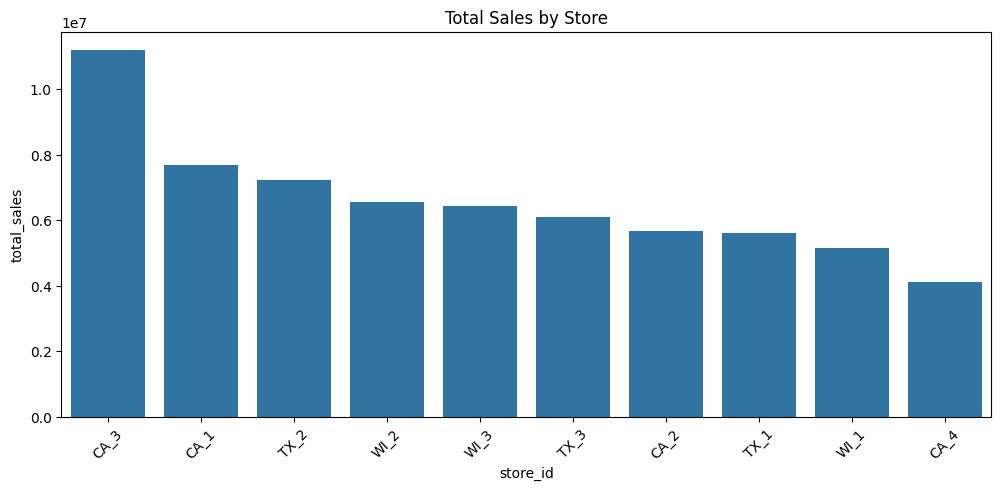

In [31]:
plt.figure(figsize=(12,5))

sns.barplot(
    data=store_sales,
    x="store_id",
    y="total_sales"
)

plt.xticks(rotation=45)

plt.title("Total Sales by Store")

plt.show()

### Category Performance

In [32]:
category_query = """
SELECT

    cat_id,

    SUM(sales) AS total_sales

FROM sales_enriched

GROUP BY cat_id

ORDER BY total_sales DESC;
"""

In [33]:
category_sales = pd.read_sql(
    category_query,
    conn
)

C:\Users\Dell\AppData\Local\Temp\ipykernel_13596\2461465782.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  category_sales = pd.read_sql(


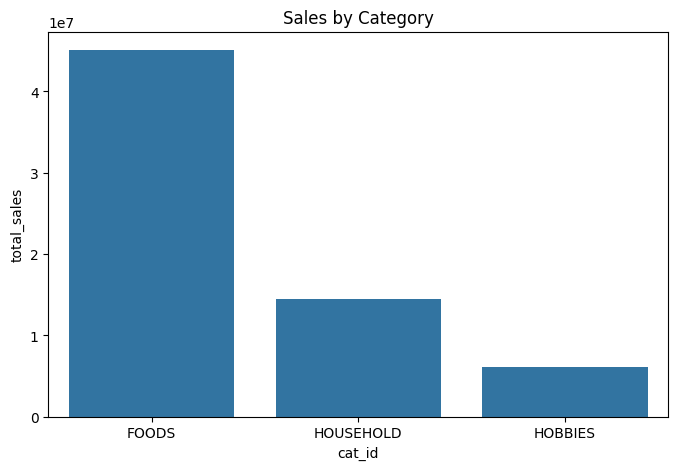

In [34]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=category_sales,
    x="cat_id",
    y="total_sales"
)

plt.title("Sales by Category")

plt.show()

### Department Performance

In [35]:
department_query = """
SELECT

    dept_id,

    SUM(sales) AS total_sales

FROM sales_enriched

GROUP BY dept_id

ORDER BY total_sales DESC;
"""

In [37]:
department_sales = pd.read_sql(
    department_query,
    conn
)

C:\Users\Dell\AppData\Local\Temp\ipykernel_13596\3892273118.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  department_sales = pd.read_sql(


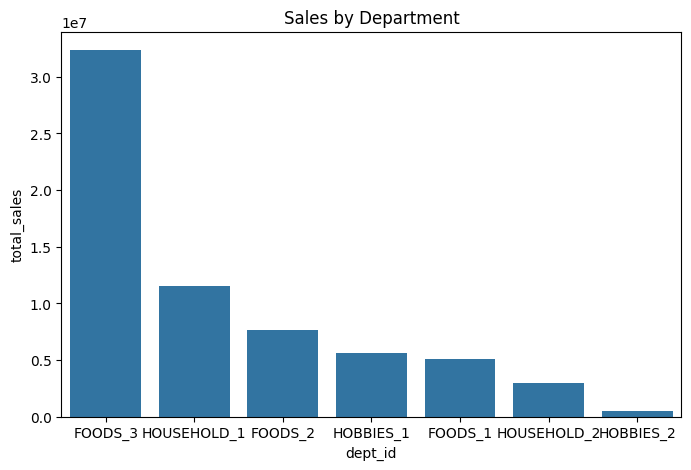

In [38]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=department_sales,
    x="dept_id",
    y="total_sales"
)

plt.title("Sales by Department")

plt.show()

### Top 20 Products

In [39]:
product_query = """
SELECT

    item_id,

    SUM(sales) AS total_sales

FROM sales_enriched

GROUP BY item_id

ORDER BY total_sales DESC

LIMIT 20;
"""

In [43]:
product_sales = pd.read_sql(
    product_query,
    conn
)

product_sales

C:\Users\Dell\AppData\Local\Temp\ipykernel_13596\1864074228.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  product_sales = pd.read_sql(


,item_id,total_sales
0,FOODS_3_090,1002529.0
1,FOODS_3_586,920242.0
2,FOODS_3_252,565299.0
3,FOODS_3_555,491287.0
4,FOODS_3_714,396172.0
5,FOODS_3_587,396119.0
6,FOODS_3_694,390001.0
7,FOODS_3_226,363082.0
8,FOODS_3_202,295689.0
9,FOODS_3_723,284333.0


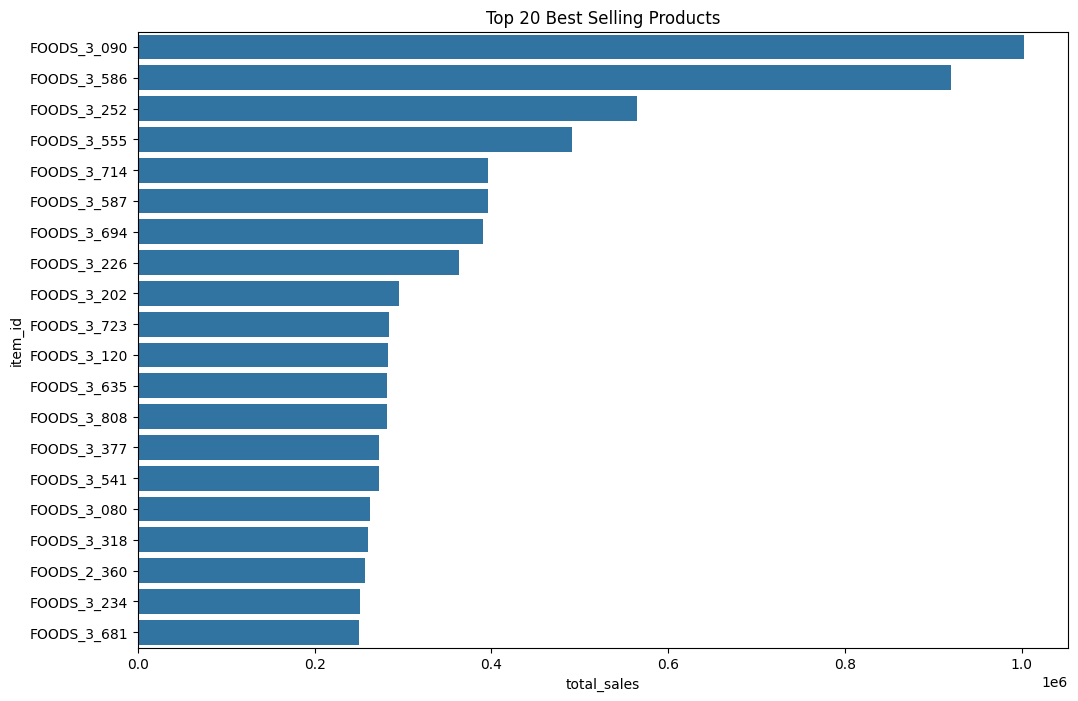

In [44]:
plt.figure(figsize=(12,8))

sns.barplot(
    data=product_sales,
    x="total_sales",
    y="item_id"
)

plt.title("Top 20 Best Selling Products")

plt.show()

📈 Trend
- Demand is increasing year over year.

📅 Weekly Pattern

- Weekend demand is significantly higher than weekdays.

📆 Monthly Pattern

- August–September are the strongest months.
- May is relatively weaker.

🛒 Store Performance

- CA_3 is by far the highest-performing store.
- CA_4 is the weakest.

🥫 Category Performance

- FOODS dominates the business.
- HOUSEHOLD is second.
- HOBBIES contributes the least.

🏬 Department Performance

- FOODS_3 is the largest department.
- HOBBIES_2 is the smallest.

🥇 Products

- A few products contribute disproportionately to sales (a classic long-tail distribution).
SNAP
- Sales are consistently higher on SNAP days across all three states.